# Attention U-Net 2D — Test (không train, chỉ tải checkpoint đã có)
Đây là bản test độc lập, tách từ `Source/File_Train/Attention_Unet2D.ipynb` (bản gốc train+test chung 1 notebook). Kiến trúc: Attention U-Net thuần (không câu nhắc, tự động hoàn toàn) — dùng làm mốc so sánh "attention chưa điều kiện hóa" trong bảng ablation (xem V7 — PSG+Attention gốc).

In [1]:
# =========================================================
# CELL 1 - SETUP (test-only: clone repo, tải dataset + checkpoint đã train)
# =========================================================
%cd /content
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("=" * 50)

# ===== CLONE REPO (nhánh attention-unet2D) =====
!git clone -b attention-unet2D https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

# ===== DATASET =====
!gdown --id 1y7wD82n51hdLcbwrQwFtm-7sBnD_OJet
!unzip -q dataset_BTXRD.zip
!mv dataset_BTXRD Prompt-Guided-XRay-Segmentation/

%cd Prompt-Guided-XRay-Segmentation
!pip install -q tqdm opencv-python matplotlib scikit-image gdown

# ===== CHECKPOINT (điền vào trước khi chạy) =====
# Upload checkpoint (att_unet_best.pth, xem Source/File_Train/Attention_Unet2D.ipynb) lên
# Google Drive rồi điền ID vào đây
import os, gdown
CKPT_ID   = '1i-jyVrZGjS6-LARFxbZX5u7RzBflJ4r7'                                            # ← CHƯA CÓ: điền ID Google Drive checkpoint (att_unet_best.pth) sau khi train xong
CKPT_PATH = 'checkpoints/att_unet_best.pth'
os.makedirs('checkpoints', exist_ok=True)
assert CKPT_ID, '❌ Chưa điền CKPT_ID — upload checkpoint lên Drive rồi điền ID vào đây'
gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f"\n✅ Checkpoint: {CKPT_PATH}  ({os.path.getsize(CKPT_PATH)//1024} KB)")
print("\nSETUP DONE!")


/content
CUDA: True
GPU: Tesla T4
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 186 (delta 64), reused 88 (delta 35), pack-reused 62 (from 1)
Receiving objects: 100% (186/186), 36.63 MiB | 32.28 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1y7wD82n51hdLcbwrQwFtm-7sBnD_OJet
From (redirected): https://drive.google.com/uc?id=1y7wD82n51hdLcbwrQwFtm-7sBnD_OJet&confirm=t&uuid=6a51f829-952a-44e9-ad21-8333dfca9d27
To: /content/dataset_BTXRD.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:16<00:00, 101MB/s]
/content/Prompt-Guided-XRay-Segme

Downloading...
From: https://drive.google.com/uc?id=1i-jyVrZGjS6-LARFxbZX5u7RzBflJ4r7
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/att_unet_best.pth
100%|██████████| 10.3M/10.3M [00:00<00:00, 27.3MB/s]


✅ Checkpoint: checkpoints/att_unet_best.pth  (10053 KB)

SETUP DONE!


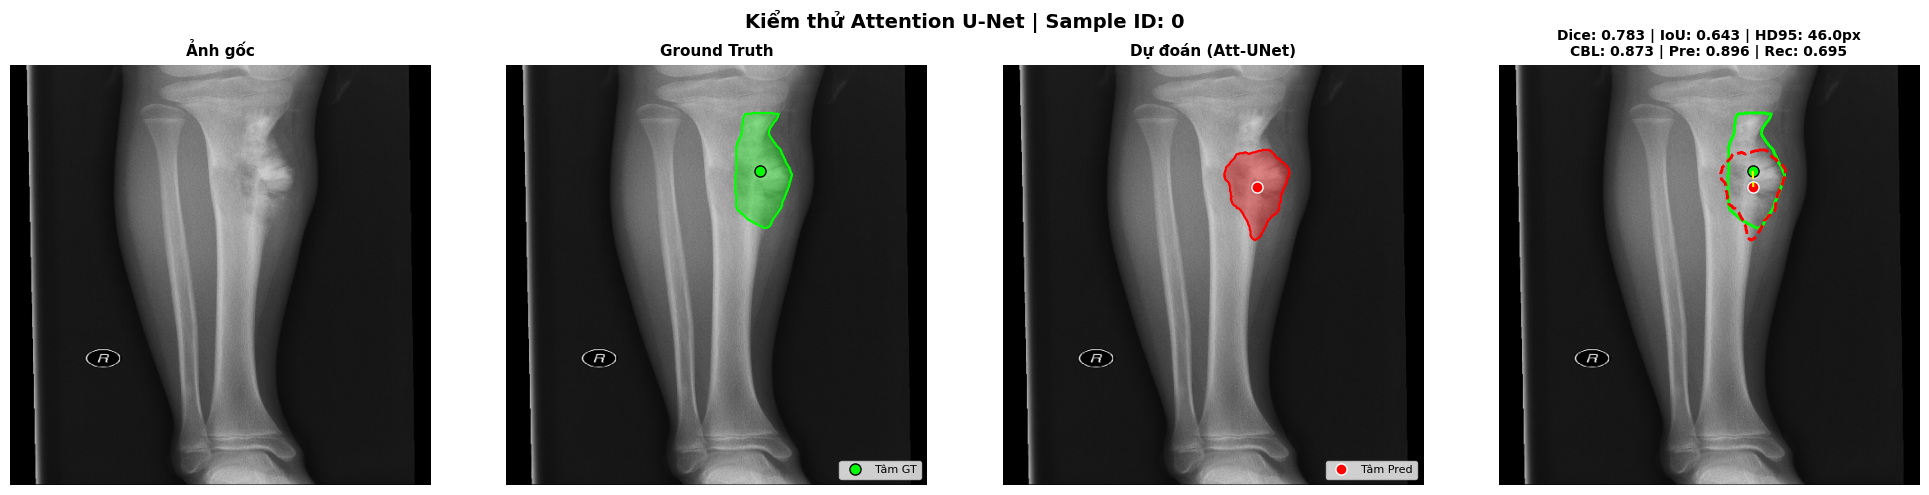

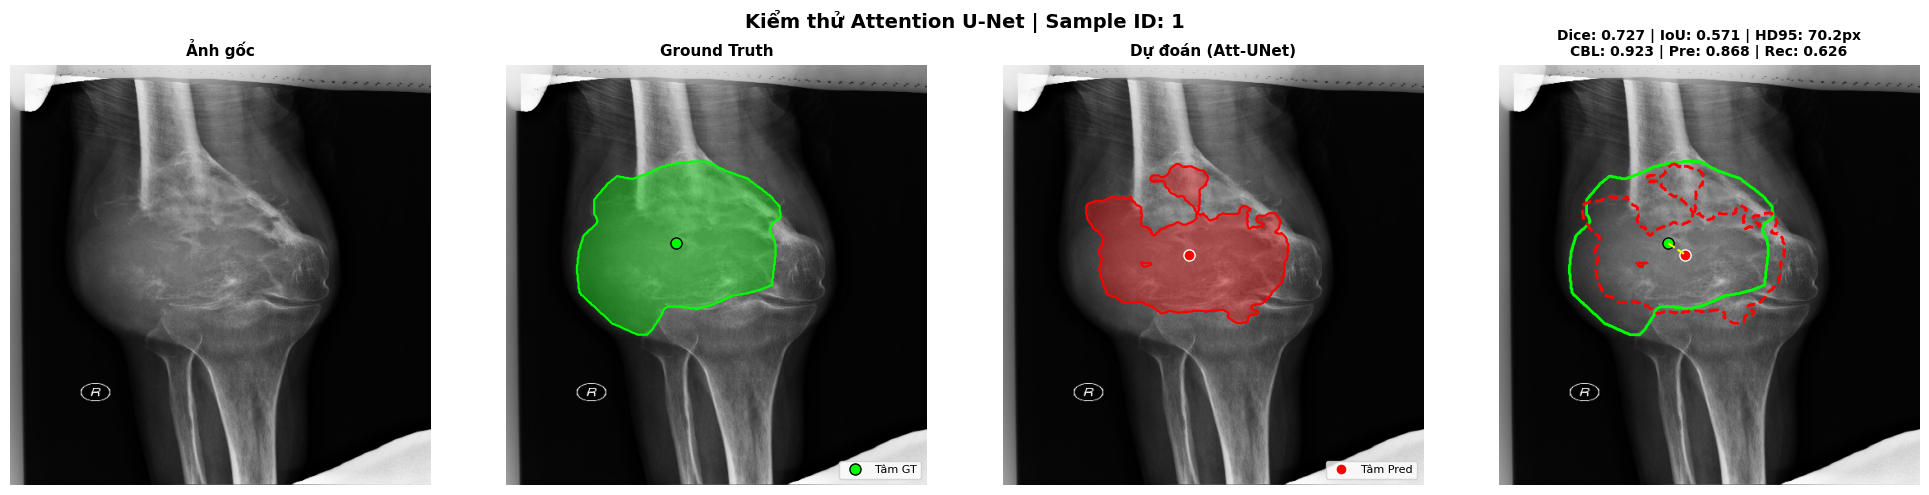

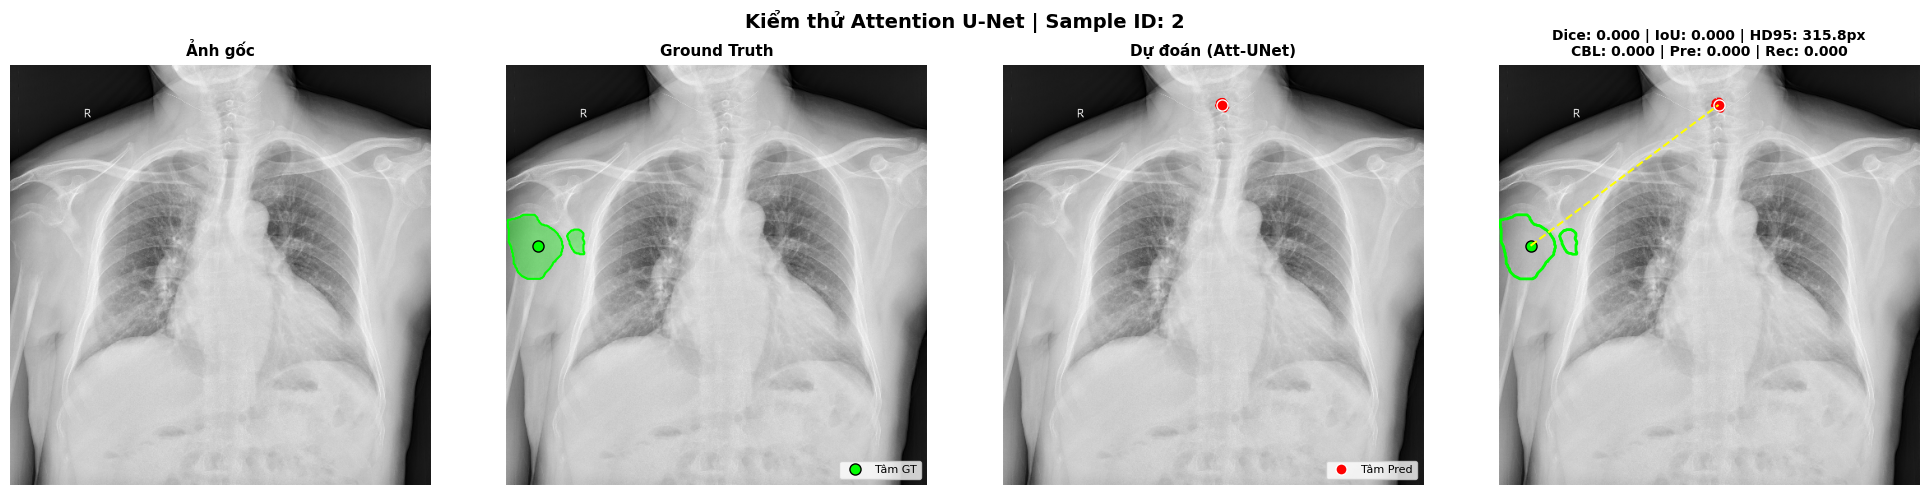

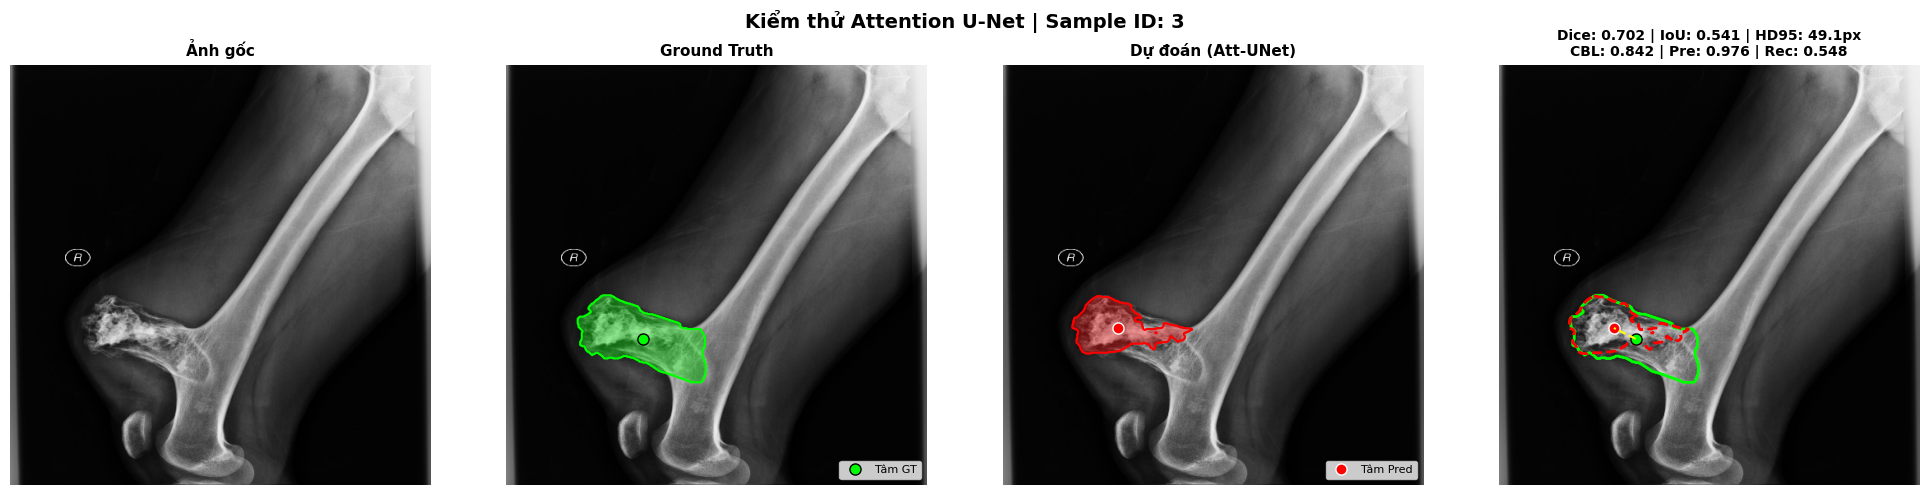

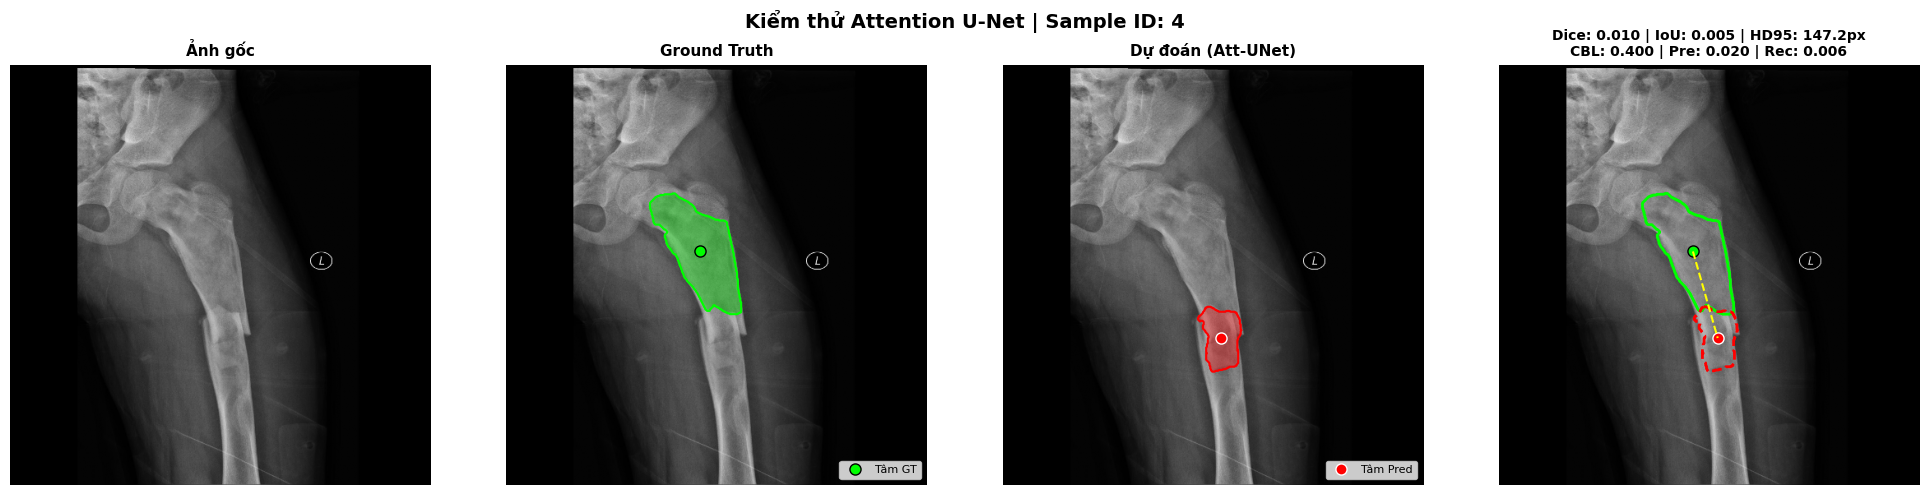

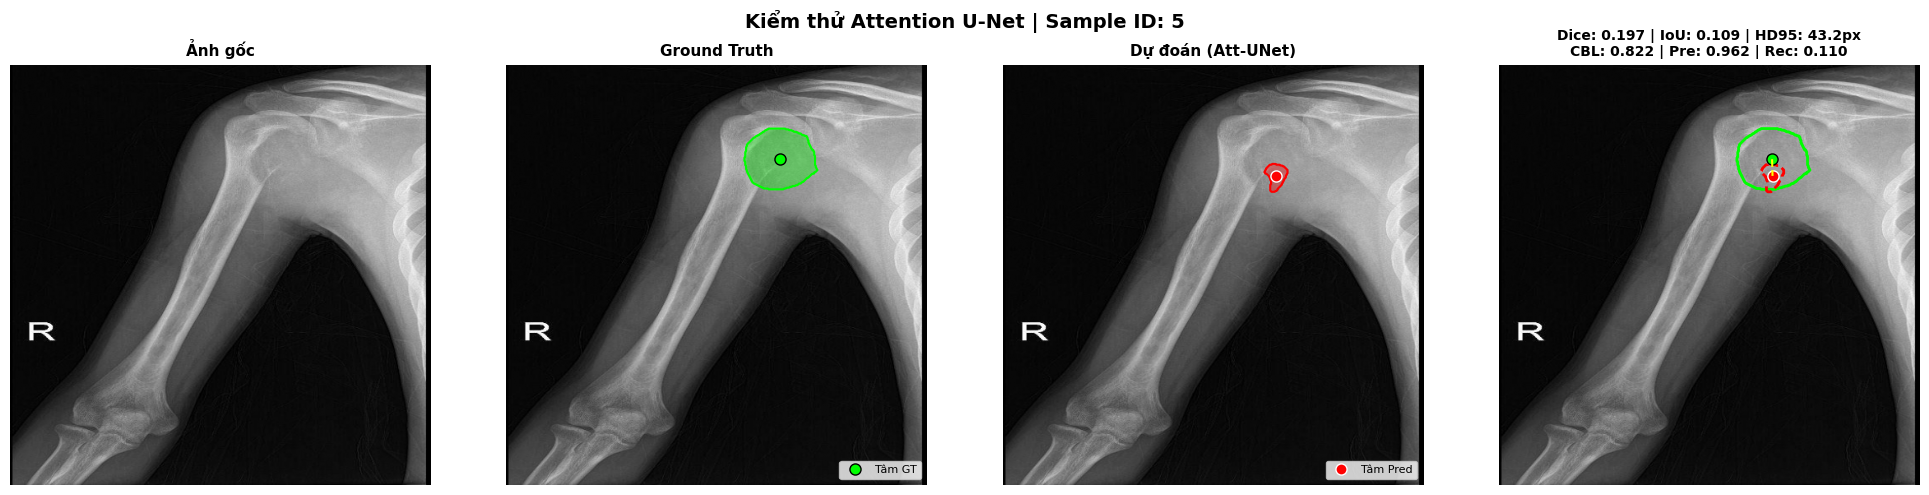

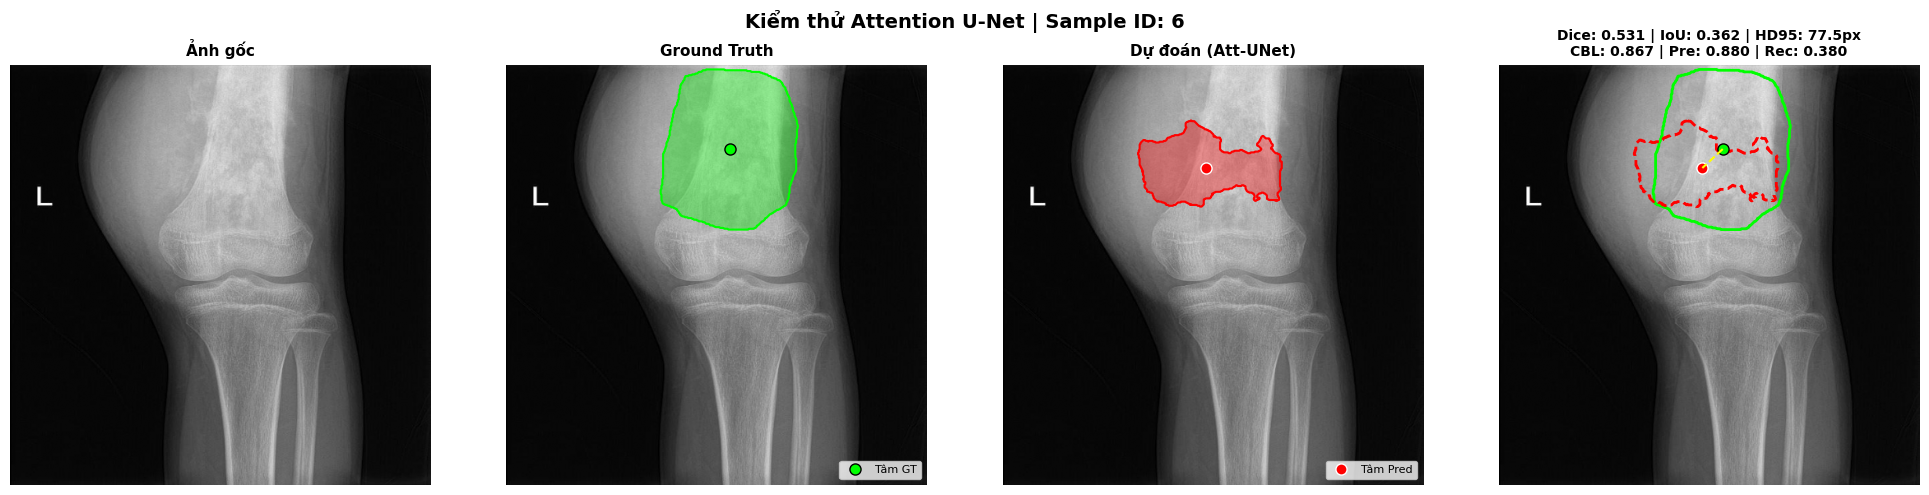

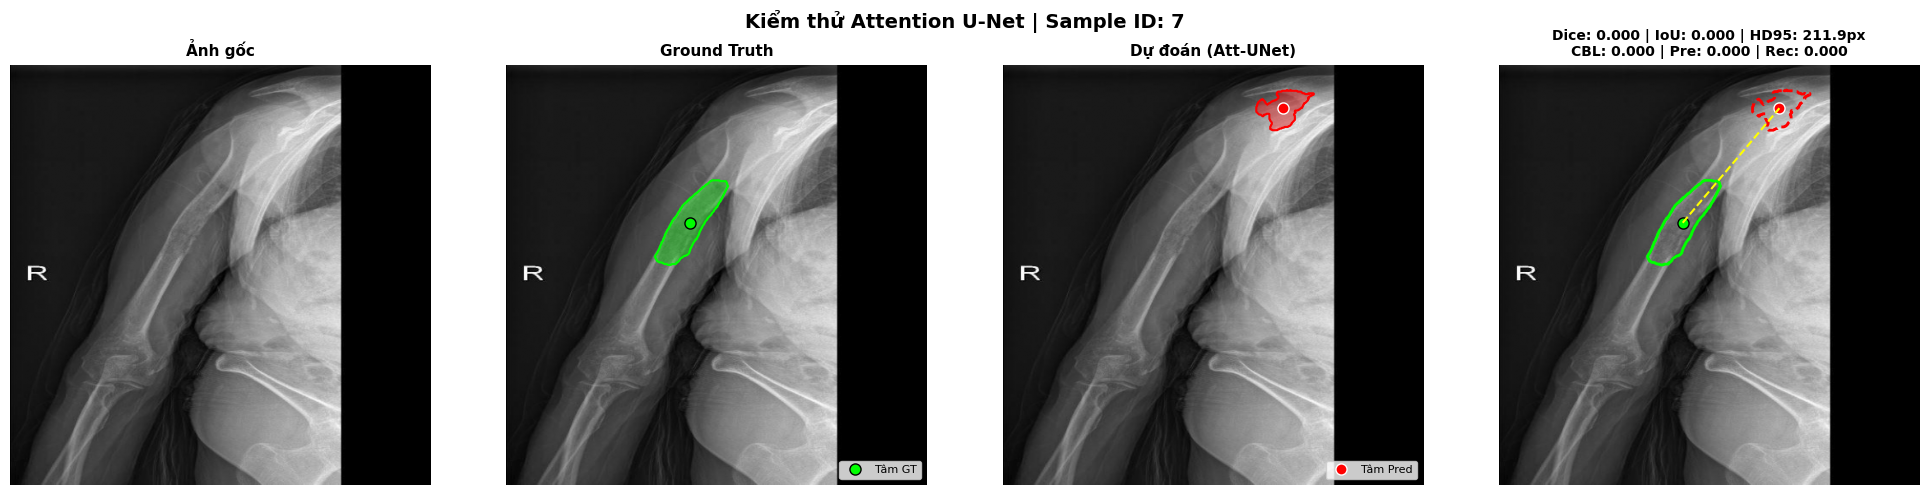

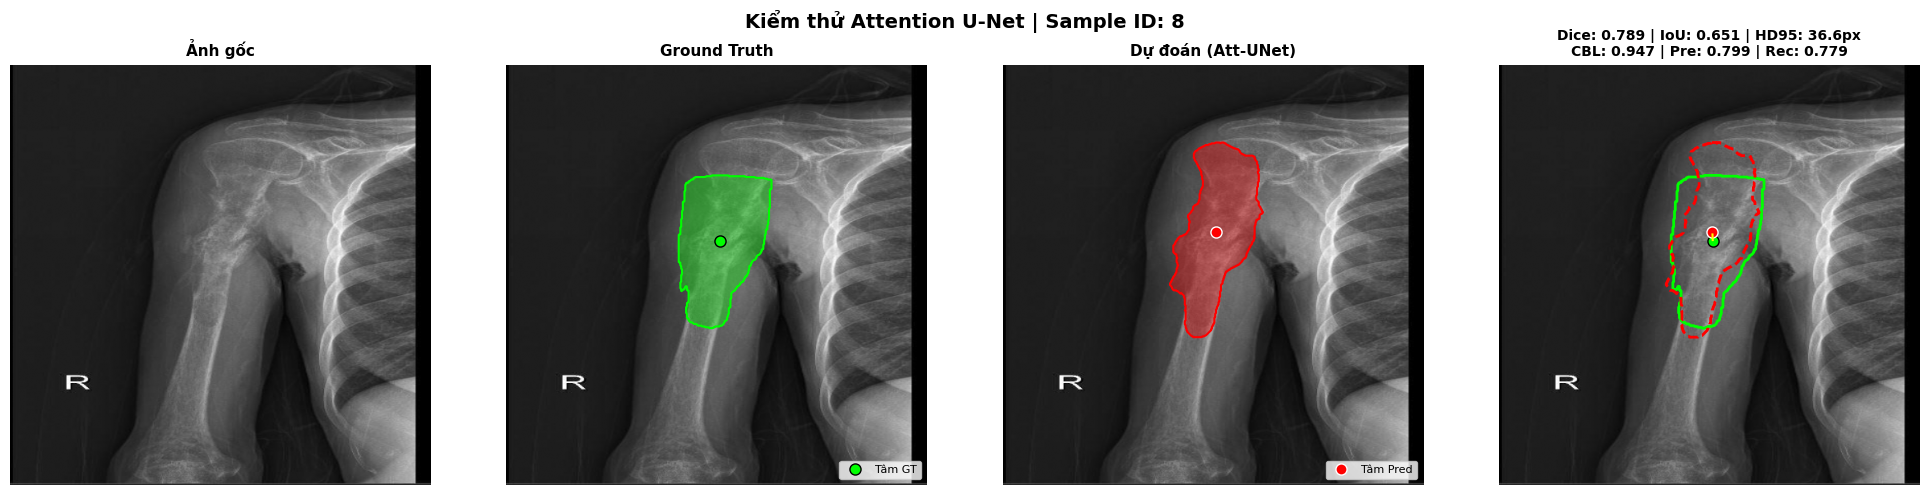

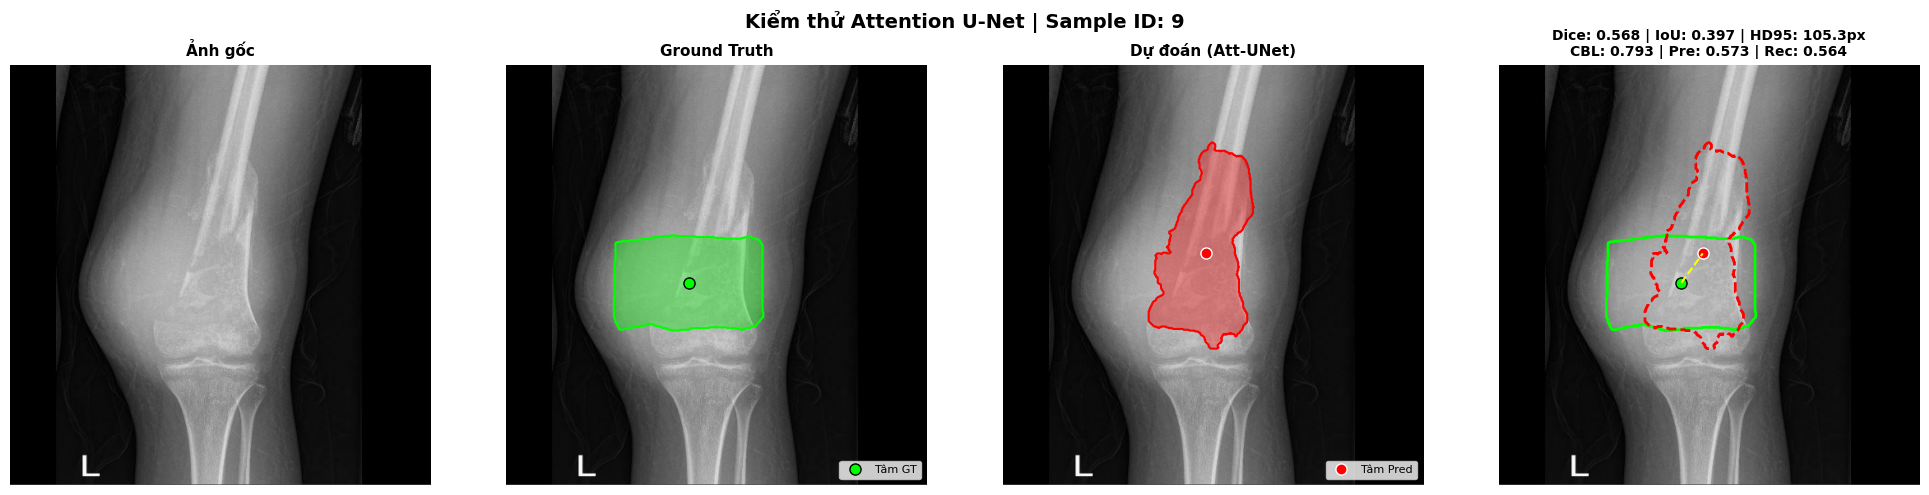


📊 FINAL TEST RESULTS - ATTENTION U-NET
Mean Dice ↑      : 0.4122
Mean IoU ↑       : 0.3291
Mean Precision ↑ : 0.5988
Mean Recall ↑    : 0.4065
Mean HD95 ↓ (px) : 136.75
Mean CBL ↑       : 0.5701
Total Samples    : 187

Ket qua da luu: results/attunet2d_results.csv
Ket qua per-image da luu: results/attunet2d_per_image.csv


In [2]:
# @title
# =========================================================
# TEST PHASE (ATTENTION U-NET 2D | ImgSize=512 | Batch=4 | Epochs≤100)
# =========================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

# Import model và dataset
from dataset import BTXRD_Dataset
from models.networks.attention_unet_2D import Attention_UNet_2D

# =========================================================
# CẤU HÌNH
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/att_unet_best.pth"
IMG_SIZE = 512  # Chú ý: File này của bạn dùng 512

# =========================================================
# HÀM HỖ TRỢ (LỌC NHIỄU & TÍNH TOÁN) - CHUẨN CHUNG
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    """Lọc sạch nhiễu viền, chỉ giữ lại cục xương to nhất để công bằng với các model khác."""
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    """Tính 95% Hausdorff Distance"""
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or not gt.any(): return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    """Tính độ lệch tâm Center-Based Localization"""
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d/gt_diag, 0.0, 1.0))

def get_centroid(binary_map: np.ndarray):
    """Lấy tọa độ tâm để vẽ lên biểu đồ"""
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

# =========================================================
# LOAD MODEL & DATASET
# =========================================================

model = Attention_UNet_2D(in_channels=1, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

test_dataset = BTXRD_Dataset(
    image_dir="dataset_BTXRD/test/images",
    mask_dir="dataset_BTXRD/test/masks",
    img_size=IMG_SIZE,
    is_train=False
)
test_dataset.images = sorted(test_dataset.images)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# =========================================================
# TEST LOOP
# =========================================================

SHOW_INDEX = list(range(10))  # 10 ảnh đầu theo thứ tự
all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []
smooth = 1e-5

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        # Đưa về Numpy
        img_np = (images[0, 0].cpu().numpy() + 1) / 2.0  # Chỉnh lại cho sáng nếu ảnh bị tối do normalize
        gm = masks[0, 0].cpu().numpy()
        pm = preds[0, 0].cpu().numpy()

        # HẬU XỬ LÝ (Lọc nhiễu mảnh nhỏ để HD95 chuẩn xác)
        pm = extract_lcc(pm)

        # Tính 4 thông số cơ bản
        tp = (pm * gm).sum()
        fp = (pm * (1 - gm)).sum()
        fn = ((1 - pm) * gm).sum()

        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou  = (tp + smooth) / (tp + fp + fn + smooth)
        pre  = (tp + smooth) / (tp + fp + smooth)
        rec  = (tp + smooth) / (tp + fn + smooth)

        # Tính khoảng cách & độ lệch tâm
        hd = calc_hd95(pm.astype(bool), gm.astype(bool))
        cbl = calc_cbl(pm.astype(bool), gm.astype(bool))

        all_dice.append(dice)
        all_iou.append(iou)
        all_pre.append(pre)
        all_rec.append(rec)
        all_hd95.append(hd)
        if cbl is not None:
            all_cbl.append(cbl)

        # =====================================================
        # TRỰC QUAN HÓA (4 CỘT - GIỐNG EXP A/B)
        # =====================================================
        if idx in SHOW_INDEX:
            cx_gt, cy_gt = get_centroid(gm)
            cx_p, cy_p   = get_centroid(pm)

            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle(f"Kiểm thử Attention U-Net | Sample ID: {idx}", fontsize=14, fontweight='bold')

            # 1. Ảnh gốc
            axes[0].imshow(img_np, cmap='gray')
            axes[0].set_title("Ảnh gốc", fontsize=11, fontweight='bold')

            # 2. Ground Truth + Tâm
            axes[1].imshow(img_np, cmap='gray')
            green = np.zeros((*gm.shape, 4), dtype=np.float32)
            green[gm == 1] = [0, 1, 0, 0.35]
            axes[1].imshow(green)
            if gm.max() > 0:
                axes[1].contour(gm, [0.5], colors='lime', linewidths=1.5)
            if cx_gt is not None:
                axes[1].plot(cx_gt, cy_gt, 'o', color='lime', ms=8, markeredgecolor='black', label='Tâm GT')
                axes[1].legend(loc='lower right', fontsize=8)
            axes[1].set_title("Ground Truth", fontsize=11, fontweight='bold')

            # 3. Dự đoán + Tâm
            axes[2].imshow(img_np, cmap='gray')
            red = np.zeros((*pm.shape, 4), dtype=np.float32)
            red[pm == 1] = [1, 0, 0, 0.35]
            axes[2].imshow(red)
            if pm.max() > 0:
                axes[2].contour(pm, [0.5], colors='red', linewidths=1.5)
            if cx_p is not None:
                axes[2].plot(cx_p, cy_p, 'o', color='red', ms=8, markeredgecolor='white', label='Tâm Pred')
                axes[2].legend(loc='lower right', fontsize=8)
            axes[2].set_title("Dự đoán (Att-UNet)", fontsize=11, fontweight='bold')

            # 4. Nét cắt so sánh + Chỉ số (Có đường nối tâm)
            axes[3].imshow(img_np, cmap='gray')
            if gm.max() > 0: axes[3].contour(gm, [0.5], colors='lime', linewidths=2)
            if pm.max() > 0: axes[3].contour(pm, [0.5], colors='red', linewidths=2, linestyles='--')
            if cx_gt is not None: axes[3].plot(cx_gt, cy_gt, 'o', color='lime', ms=8, markeredgecolor='black')
            if cx_p is not None:  axes[3].plot(cx_p, cy_p, 'o', color='red', ms=8, markeredgecolor='white')

            # Vẽ đường nối 2 tâm để hiển thị độ lệch
            if cx_gt is not None and cx_p is not None:
                axes[3].plot([cx_gt, cx_p], [cy_gt, cy_p], '--', color='yellow', lw=1.5)

            title_str = (f"Dice: {dice:.3f} | IoU: {iou:.3f} | HD95: {hd:.1f}px\n"
                         f"CBL: {cbl:.3f} | Pre: {pre:.3f} | Rec: {rec:.3f}")
            axes[3].set_title(title_str, fontsize=10, fontweight='bold')

            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()

# =========================================================
# FINAL REPORT (TỔNG HỢP CHO LUẬN VĂN)
# =========================================================
print("\n" + "=" * 60)
print("📊 FINAL TEST RESULTS - ATTENTION U-NET")
print("=" * 60)
print(f"Mean Dice ↑      : {np.mean(all_dice):.4f}")
print(f"Mean IoU ↑       : {np.mean(all_iou):.4f}")
print(f"Mean Precision ↑ : {np.mean(all_pre):.4f}")
print(f"Mean Recall ↑    : {np.mean(all_rec):.4f}")
print(f"Mean HD95 ↓ (px) : {np.mean(all_hd95):.2f}")
print(f"Mean CBL ↑       : {np.mean(all_cbl):.4f}")
print(f"Total Samples    : {len(all_dice)}")
print("=" * 60)
# =========================================================
# LUU KET QUA CSV (LUAN VAN)
# =========================================================
import csv, os
os.makedirs("results", exist_ok=True)
csv_path = "results/attunet2d_results.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["model", "dice", "iou", "precision", "recall", "hd95", "cbl", "n_samples"])
    writer.writerow([
        "AttUNet2D",
        f"{np.mean(all_dice):.4f}",
        f"{np.mean(all_iou):.4f}",
        f"{np.mean(all_pre):.4f}",
        f"{np.mean(all_rec):.4f}",
        f"{np.mean(all_hd95):.4f}",
        f"{np.mean(all_cbl):.4f}",
        len(all_dice)
    ])
print(f"\nKet qua da luu: {csv_path}")

# =========================================================
# LUU KET QUA PER-IMAGE CSV (phuc vu kiem dinh thong ke neu can)
# =========================================================
img_names = [os.path.basename(p) for p in test_dataset.images]
per_image_path = "results/attunet2d_per_image.csv"
with open(per_image_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["img_name", "dice", "iou", "precision", "recall", "hd95"])
    for i in range(len(all_dice)):
        writer.writerow([
            img_names[i] if i < len(img_names) else f"idx_{i}",
            f"{all_dice[i]:.6f}", f"{all_iou[i]:.6f}",
            f"{all_pre[i]:.6f}", f"{all_rec[i]:.6f}", f"{all_hd95[i]:.6f}"
        ])
print(f"Ket qua per-image da luu: {per_image_path}")
